## Metodo di bisezione

1. **INPUT**: intervallo iniziale $[a,b]=[a_1,b_1]$; una function per calcolare la funzione oggetto della ricerca; il parametro di tolleranza
2. Si ricava il numero di iterazioni sufficienti a soddisfare la tolleranza
3. Per ogni iterazione $k$:
4. Si calcola il punto medio $c_k$ dell'intervallo di ricerca $[a_k,b_k]$
5. Si definisce il nuovo intervallo di ricerca $[a_{k+1},b_{k+1}]$ come quello tra i due sottointervalli $[a_k,c_k]$, $[c_k,b_k]$ in cui sono soddisfatte le ipotesi del teorema del valor medio:

$$
\left[a_{k+1},b_{k+1}\right] = \left\{
\begin{array}{ll}
\left[a_k,c_k\right] &  \text{ se } f(c_k)\cdot f(a_k) < 0 \\
\left[c_k,b_k\right] & \text{ se } f(c_k)\cdot f(b_k) < 0
\end{array}\right.
$$


In [24]:
import numpy as np

def bisezione(f, a, b, tol=1e-6, max_iter=None, rf=False, verbose=False):
    """
    Metodo di bisezione / regula falsi per la ricerca di zeri.

    Parametri:
    - f: funzione
    - a, b: estremi iniziali
    - tol: tolleranza sull'errore (lunghezza intervallo)
    - max_iter: numero massimo iterazioni (opzionale)
    - rf: se True usa regula falsi, altrimenti bisezione
    - verbose: stampa dettagli iterazioni

    Ritorna:
    - c: approssimazione della radice
    """

    fa = f(a)
    fb = f(b)

    # Controllo condizioni iniziali
    if fa * fb > 0:
        raise ValueError("f(a) e f(b) devono avere segno opposto")

    # Numero iterazioni (solo per bisezione ha senso teorico)
    if max_iter is None:
        max_iter = int(np.log2((b - a) / tol)) + 1

    for k in range(max_iter):

        # Calcolo punto
        if rf:
            # Regula falsi (più informata ma può stagnare)
            c = b - fb * (b - a) / (fb - fa)
        else:
            # Bisezione (più stabile)
            c = a + (b - a) / 2

        fc = f(c)

        if verbose:
            print(f"{k})\tc = {c},\tf(c) = {fc}")

        # Criterio di arresto (più robusto)
        if abs(fc) < tol or (b - a) / 2 < tol:
            return c

        # Aggiornamento intervallo
        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc

    # Se raggiungo max_iter
    return c

**Esperimento numerico**
Applichiamo il metodo di bisezione alla ricerca di uno zero della funzione seguente
$$f(x) = \sin(x) - \left(\frac x 2\right)^2$$
nell'intervallo $[1,2]$

In [25]:
# Esempio funzione
def f_esempio(x):
    return np.sin(x) - (x / 2)**2

a, b = 1, 2

Verifichiamo graficamente che nell'intervallo $[1,2]$ esista almeno una rafice della funzione $f$

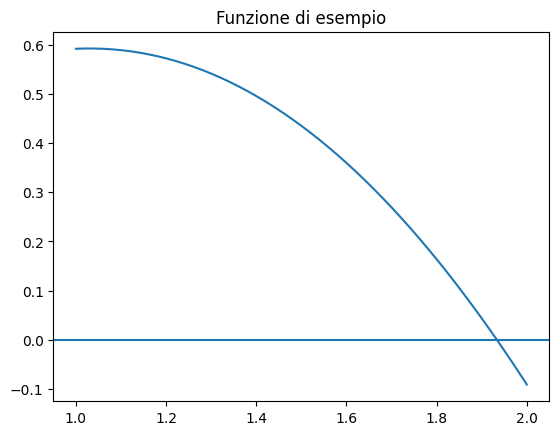

In [26]:
import matplotlib.pyplot as plt

x = np.linspace(a, b, 200)
y = f_esempio(x)

plt.axhline(0)  # asse x
plt.plot(x, y)
plt.title("Funzione di esempio")
plt.show()

In [27]:
sol_bis = bisezione(f_esempio, a, b, tol=1e-6, verbose=True)
print(f"Soluzione (bisezione): {sol_bis}\n")

sol_rf = bisezione(f_esempio, a, b, tol=1e-6, rf=True, verbose=True)
print(f"Soluzione (regula falsi): {sol_rf}")

0)	c = 1.5,	f(c) = 0.43499498660405445
1)	c = 1.75,	f(c) = 0.21836094687393692
2)	c = 1.875,	f(c) = 0.07517953160969382
3)	c = 1.9375,	f(c) = -0.0049622816376238
4)	c = 1.90625,	f(c) = 0.035813793060754495
5)	c = 1.921875,	f(c) = 0.015601412838988415
6)	c = 1.9296875,	f(c) = 0.005363397451792373
7)	c = 1.93359375,	f(c) = 0.00021150537499570188
8)	c = 1.935546875,	f(c) = -0.0023726525881073712
9)	c = 1.9345703125,	f(c) = -0.0010798895547514675
10)	c = 1.93408203125,	f(c) = -0.00043402105622292186
11)	c = 1.933837890625,	f(c) = -0.00011121507961475707
12)	c = 1.9337158203125,	f(c) = 5.0155838263177266e-05
13)	c = 1.93377685546875,	f(c) = -3.0526948073039684e-05
14)	c = 1.933746337890625,	f(c) = 9.815113250821739e-06
15)	c = 1.9337615966796875,	f(c) = -1.0355750372781358e-05
16)	c = 1.9337539672851562,	f(c) = -2.7027680138402843e-07
Soluzione (bisezione): 1.9337539672851562

0)	c = 1.8670388611329274,	f(c) = 0.08498162232233175
1)	c = 1.9313545683871074,	f(c) = 0.0031674065233533444
2)	c 

## Metodo di Newton
$$x_{k+1} = x_k - \frac{f(x_k)}{f'(x_k)} $$

In [28]:
def newton(f,df,x0,tol,Nmax):
    """Implementazione metodo di Newton

    Args:
        f (function): Funzione di interesse
        df (function): Derivata della funzione
        x0 (float): Punto iniziale
        tol (float): Tolleranza
        Nmax (int): Numero massimo di iterazioni

    Returns:
        float: Approssimazione della radice trovata
    """
    
    # Valori iniziali per determinare lo spostamento
    fx_k  = f(x0)
    dfx_k = df(x0)
    
    for k in range(Nmax):
        
        # Calcolo il prossimo spostamento
        x = x0 - fx_k / dfx_k
        
        print(f"{k})\tfx_k = {fx_k}\tx_k = {x0}")
    
        # Calcolo della derivata
        fx_k  = f(x)
        dfx_k = df(x)
        
        # Controllo delle condizioni di arresto
        if np.abs(x - x0) / np.abs(x) < tol and np.abs(fx_k) < tol:
            # Quando la distanza relativa tra due iterate va sotto la tolleranza
            # e quando il valore della funzione è più piccolo della tolleranza
            # (difatti il residuo in questo problema è il valore della funzione).
            print(f"{k+1})\tfx_k = {fx_k}\tx_k+1 = {x}")
            return x
        
        x0 = x
    
    print("Numero massimo di iterate raggiunto. Tolleranza non soddisfatta!")
    return x

In [29]:
def df_esempio(x):
  return np.cos(x)-x/2

x0, tol = 1.5, 1e-4

# la scelta del punto iniziale è dovuta al fatto che in questo modo newton è alla 
# pari col metodo di bisezione, così da poterli confrontare più correttamente.

In [30]:
sol_newton = newton(f_esempio, df_esempio, x0, tol, 15)
print(f"Soluzione (newton): {sol_newton}")

0)	fx_k = 0.43499498660405445	x_k = 1.5
1)	fx_k = -0.30320162752935753	x_k = 2.1403927723880054
2)	fx_k = -0.024370564236055103	x_k = 1.952008946405626
3)	fx_k = -0.00023375210571285887	x_k = 1.933930573929843
4)	fx_k = -2.2423316314856834e-08	x_k+1 = 1.933753779789742
Soluzione (newton): 1.933753779789742


## Funzioni di libreria in SciPy

Metodi per le equazioni nonlineari sono implementati in `scipy.optimize`

`root_scalar` per le equazioni di una sola variabile  [documentazione](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.root_scalar.html#scipy.optimize.root_scalar)

`fsolve` può risolvere anche sistemi di equazioni nonlineari in più variabili [documentazione](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.fsolve.html)

In [31]:
from scipy.optimize import root_scalar

sol_root = root_scalar(f_esempio,bracket=[a,b],method="bisect",rtol=tol)
print(sol_root.root,sol_root.iterations,sol_root.function_calls)

sol_root = root_scalar(f_esempio,x0=x0,fprime=df_esempio,method="newton",rtol=tol)
print(sol_root.root,sol_root.iterations,sol_root.function_calls)


1.9337158203125 13 15
1.933753779789742 4 8


In [32]:
from scipy.optimize import fsolve
sol_fsolve = fsolve(f_esempio,x0,xtol=tol,fprime=df_esempio,full_output=True)
#root, info, ier, msg = fsolve(..., full_output=True)
print(sol_fsolve[0])
print(sol_fsolve[1]["nfev"],sol_fsolve[1]["njev"])


[1.93375376]
9 1


## Esercizi suggeriti

Implementare il metodo di regula falsi e il metodo delle secanti ed aggiungerli al confronto numerico.